<a href="https://colab.research.google.com/github/Hackathon-05-06-2026/Hackathon_Files/blob/main/Decision_Tree_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Loaded Training Set from: /content/drive/MyDrive/Hackathon_05 06/super_dataset_C_train.csv
Tuned model re-trained successfully and active in memory.


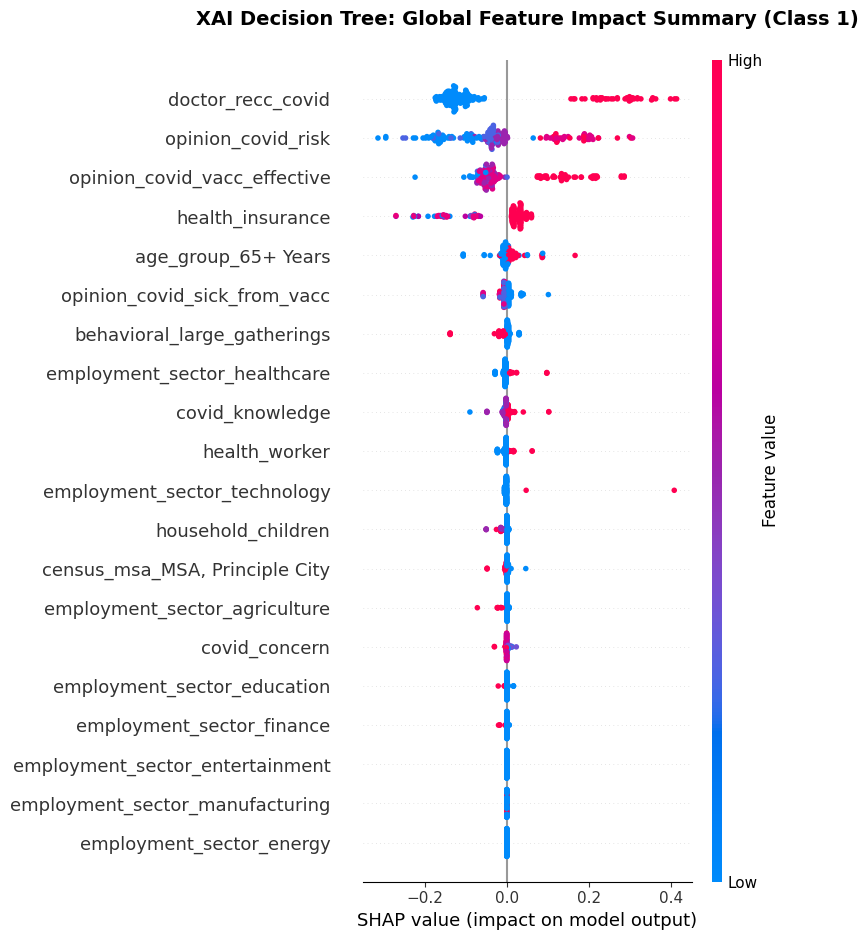

SHAP summary plot exported directly to:
   /content/drive/MyDrive/Hackathon_05 06/decision_tree_shap_xai.png


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

#install SHAP
!pip install -q shap
import shap

drive.mount('/content/drive')

#Load dataset
search_train = '/content/drive/MyDrive/*Dataset*C*/super_dataset_C_train.csv'
train_files = glob.glob(search_train) or glob.glob('/content/drive/MyDrive/Hackathon_05*06/super_dataset_C_train.csv')

if len(train_files) > 0:
    file_path = train_files[0]
    df_train = pd.read_csv(file_path)
    print(f"Loaded Training Set from: {file_path}")
else:
    raise FileNotFoundError("could not find 'super_dataset_C_train.csv' in the shared Drive.")

#seperate tgt variable and feature variables
y_train_full = df_train['covid_vaccine']
X_train_full = df_train.drop(columns=['covid_vaccine'])

#instantiate model with best parameters
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

best_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)
best_dt.fit(X_train, y_train)
print("Tuned model re-trained successfully and active in memory.")

#SHAP tree explainer

explainer = shap.TreeExplainer(best_dt)

#200-samples slice of validation entries
X_val_sample = X_val.sample(200, random_state=42)
shap_values = explainer(X_val_sample)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif hasattr(shap_values, 'values') and len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

#render and export beeswarm chart
plt.figure(figsize=(11, 7))

#global importance distribution trends
shap.summary_plot(shap_values_to_plot, X_val_sample, show=False)

plt.title("XAI Decision Tree: Global Feature Impact Summary (Class 1)", fontweight='bold', fontsize=14, pad=25)
plt.tight_layout()

#save image
shap_plot_path = file_path.replace('super_dataset_C_train.csv', 'decision_tree_shap_xai.png')
plt.savefig(shap_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"SHAP summary plot exported directly to:\n   {shap_plot_path}")